
# EDA: Furlong (2025) NRC vs. DeBortoli Range Comparison (`furlong2025_nrc_vs_debortoli_range_comparison.csv`)

A 2-row table comparing the parameter range of the NRC source tube database
against the DeBortoli rectangular-channel target range. Already stored as
explicit `_min`/`_max` column pairs — no string parsing needed.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/furlong2025_nrc_vs_debortoli_range_comparison")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "furlong2025_nrc_vs_debortoli_range_comparison.csv")
df

,Dataset,Dh_mm_max,Dh_mm_min,L_m_max,L_m_min,P_MPa_max,P_MPa_min,G_kg_m2s_max,G_kg_m2s_min,DHsubin_kJkg_max,DHsubin_kJkg_min,xe_cr_max,xe_cr_min,CHF_kW_m2_max,CHF_kW_m2_min
0,NRC_source_tube,16.00,2.00,20.00,0.05,20.00,0.01,7964,8,1644.0,-1211.00,0.99,-0.50,16339,50
1,DeBortoli_target_rectangular,4.66,2.42,0.69,0.15,13.79,4.12,6487,23,1521.5,28.41,0.99,0.01,7772,151


## 2. Range Comparison

In [2]:
def plot_range_bars(ax, labels, mins, maxs, title, xlabel=""):
    y = np.arange(len(labels))
    ax.hlines(y, mins, maxs, color="#4C72B0", linewidth=6)
    ax.plot(mins, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.plot(maxs, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

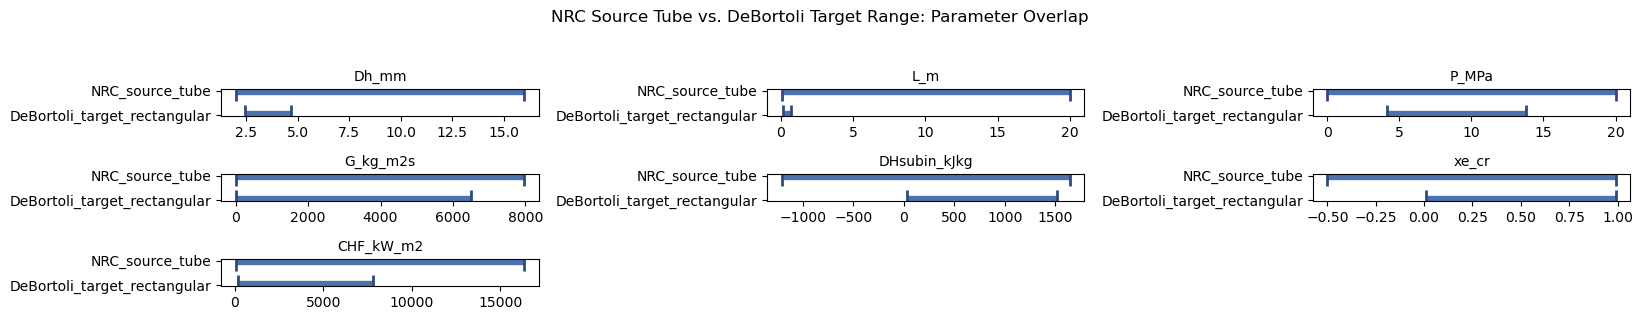

In [3]:
variables = ["Dh_mm", "L_m", "P_MPa", "G_kg_m2s", "DHsubin_kJkg", "xe_cr", "CHF_kW_m2"]
ncols = 3
nrows = -(-len(variables) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 3))
axes = np.array(axes).reshape(-1)
for ax, var in zip(axes, variables):
    plot_range_bars(ax, df["Dataset"], df[f"{var}_min"], df[f"{var}_max"], var)
for ax in axes[len(variables):]:
    ax.axis("off")
fig.suptitle("NRC Source Tube vs. DeBortoli Target Range: Parameter Overlap", y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "nrc_vs_debortoli_ranges.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Takeaways

- Where the DeBortoli target range sits fully inside the NRC source range for
  a variable, extrapolation risk is low; where it extends beyond (check
  `L_m`, `Dh_mm` in particular — rectangular channels vs. round tubes),
  a model trained only on the NRC tube data would be extrapolating out of
  domain for that variable.
- This table is purpose-built for extrapolation-risk assessment, not for
  statistical distribution analysis — the range-bar comparison above is the
  primary artifact.
